# SRTM

https://dwtkns.com/srtm30m/

https://wiki.openstreetmap.org/wiki/Contour_relief_maps_using_mapnik

The following steps download a DEM (30 m pixels) from the Shuttle Radar Topography Mission (SRTM) project and calculate contours.

$ eio clip -o benbulbin_2.tif --bounds -8.495 54.3574 -8.4632 54.3697

$ gdal_contour -i 20 -a height benbulbin_2.tif benbulbin_2_20_contour.shp


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pyproj

In [2]:
df = gpd.read_file("benbulbin_2_20_contour.shp")

In [3]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   ID        27 non-null     int32   
 1   height    27 non-null     float64 
 2   geometry  27 non-null     geometry
dtypes: float64(1), geometry(1), int32(1)
memory usage: 672.0 bytes


In [4]:
df.to_file("b_2_20.geojson", driver="GeoJSON")

In [5]:
sdf = df.sort_values(by="height", ascending=False)
sdf.head()

,ID,height,geometry
5,5,520.0,"LINESTRING (-8.47306 54.36417, -8.47306 54.364..."
6,6,500.0,"LINESTRING (-8.46917 54.3625, -8.46917 54.3625..."
7,7,480.0,"LINESTRING (-8.46597 54.35944, -8.46611 54.359..."
26,26,480.0,"LINESTRING (-8.4638 54.35764, -8.4638 54.35778..."
25,25,460.0,"LINESTRING (-8.46556 54.35764, -8.46556 54.357..."


In [6]:
sdf

,ID,height,geometry
5,5,520.0,"LINESTRING (-8.47306 54.36417, -8.47306 54.364..."
6,6,500.0,"LINESTRING (-8.46917 54.3625, -8.46917 54.3625..."
7,7,480.0,"LINESTRING (-8.46597 54.35944, -8.46611 54.359..."
26,26,480.0,"LINESTRING (-8.4638 54.35764, -8.4638 54.35778..."
25,25,460.0,"LINESTRING (-8.46556 54.35764, -8.46556 54.357..."
24,24,440.0,"LINESTRING (-8.46694 54.35764, -8.46694 54.357..."
23,23,420.0,"LINESTRING (-8.46833 54.35764, -8.46833 54.357..."
22,22,400.0,"LINESTRING (-8.4695 54.35764, -8.4695 54.35778..."
21,21,380.0,"LINESTRING (-8.47069 54.35764, -8.47069 54.357..."
20,20,360.0,"LINESTRING (-8.47181 54.35764, -8.47181 54.357..."


In [7]:
sdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
sdf.centroid

/tmp/ipykernel_24810/1954740652.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sdf.centroid


5     POINT (-8.47364 54.36478)
6     POINT (-8.47397 54.36447)
7     POINT (-8.47505 54.36353)
26    POINT (-8.46385 54.35827)
25    POINT (-8.47535 54.36314)
24    POINT (-8.47595 54.36321)
23    POINT (-8.47653 54.36331)
22    POINT (-8.47689 54.36342)
21    POINT (-8.47735 54.36359)
20    POINT (-8.47783 54.36378)
19    POINT (-8.47835 54.36398)
18    POINT (-8.47879 54.36426)
17    POINT (-8.47913 54.36454)
16     POINT (-8.4795 54.36486)
15    POINT (-8.48432 54.36385)
3       POINT (-8.46651 54.368)
14     POINT (-8.48554 54.3641)
1     POINT (-8.46467 54.36924)
13     POINT (-8.4865 54.36416)
12    POINT (-8.48785 54.36404)
2     POINT (-8.49208 54.36833)
0     POINT (-8.48667 54.36953)
4     POINT (-8.49082 54.36701)
11    POINT (-8.48992 54.35989)
10    POINT (-8.49058 54.35953)
9     POINT (-8.49156 54.35914)
8     POINT (-8.49328 54.35831)
dtype: geometry

In [9]:
crs_26917 = pyproj.CRS.from_epsg(26917)
points = df.to_crs(crs_26917)
points["centroid"] = points.centroid
points.head()

,ID,height,geometry,centroid
0,0,180.0,"LINESTRING (4502406.61 8643156.927, 4502423.93...",POINT (4502452.176 8643162.55)
1,1,240.0,"LINESTRING (4503005.638 8644704.936, 4503022.9...",POINT (4503106.778 8644746.528)
2,2,180.0,"LINESTRING (4502456.151 8642718.919, 4502456.1...",POINT (4502452.232 8642708.802)
3,3,260.0,"LINESTRING (4502886.928 8644398.005, 4502904.2...",POINT (4503227.867 8644561.03)
4,4,180.0,"LINESTRING (4502845.354 8642300.533, 4502849.2...",POINT (4502645.51 8642747.267)


In [10]:
geopoints = points.to_crs(df.crs)

In [11]:
sdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 27 entries, 5 to 8
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   ID        27 non-null     int32   
 1   height    27 non-null     float64 
 2   geometry  27 non-null     geometry
dtypes: float64(1), geometry(1), int32(1)
memory usage: 756.0 bytes


/tmp/ipykernel_24810/2754557818.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plt.scatter(x=geopoints.centroid.x, y=geopoints.centroid.y)
/tmp/ipykernel_24810/2754557818.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ax.annotate(str(height), (geopoints.centroid.x[i], geopoints.centroid.y[i]))


0

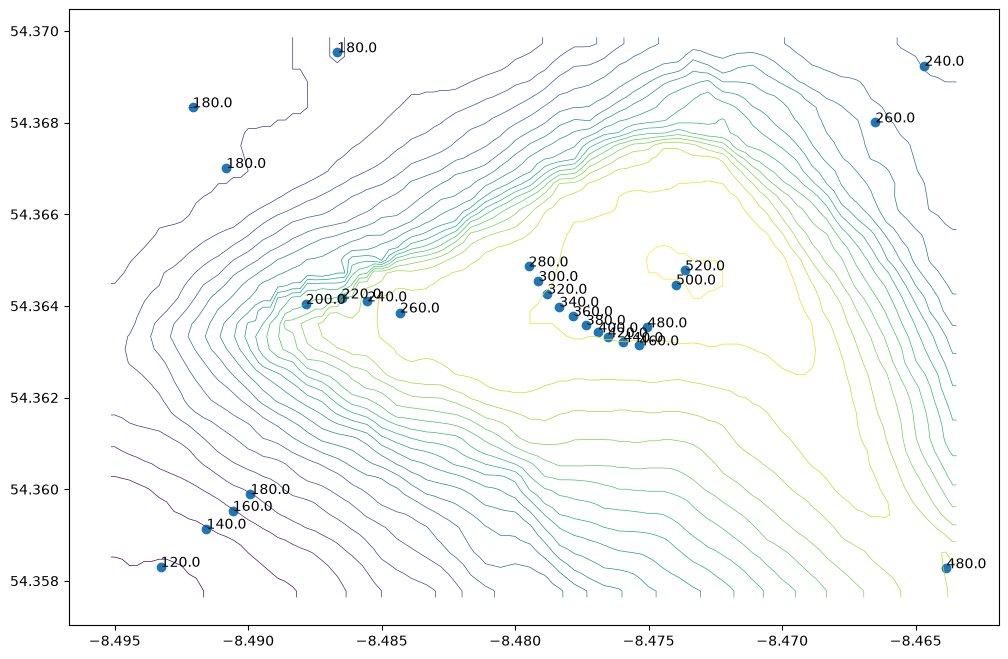

In [12]:
fig, ax = plt.subplots(figsize=(12, 12))
x = sdf.plot(ax=ax, column="height", linewidth=0.5)
# print(geopoints.centroid.y[:10])
plt.scatter(x=geopoints.centroid.x, y=geopoints.centroid.y)
for i, height in enumerate(geopoints.height):
    ax.annotate(str(height), (geopoints.centroid.x[i], geopoints.centroid.y[i]))
len(x.get_lines())

/tmp/ipykernel_24810/4138300093.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plt.scatter(x=geopoints.centroid.x, y=geopoints.centroid.y)


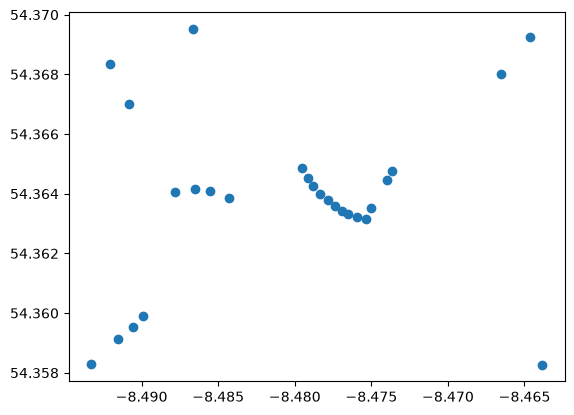

In [13]:
plt.scatter(x=geopoints.centroid.x, y=geopoints.centroid.y)

<Axes: >

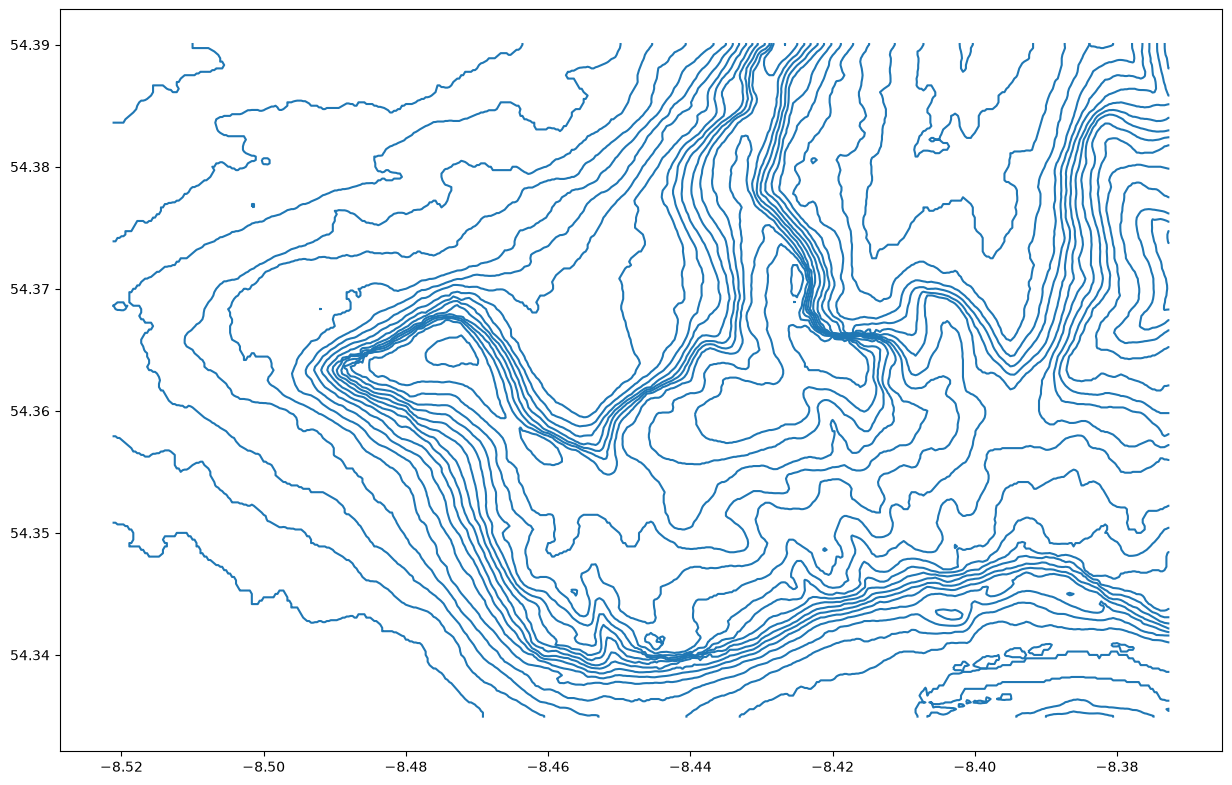

In [14]:
fig, ax = plt.subplots(figsize=(15, 15))
df = gpd.read_file("benbulbin_1_30_contour.shp")
df.plot(ax=ax)

<Axes: >

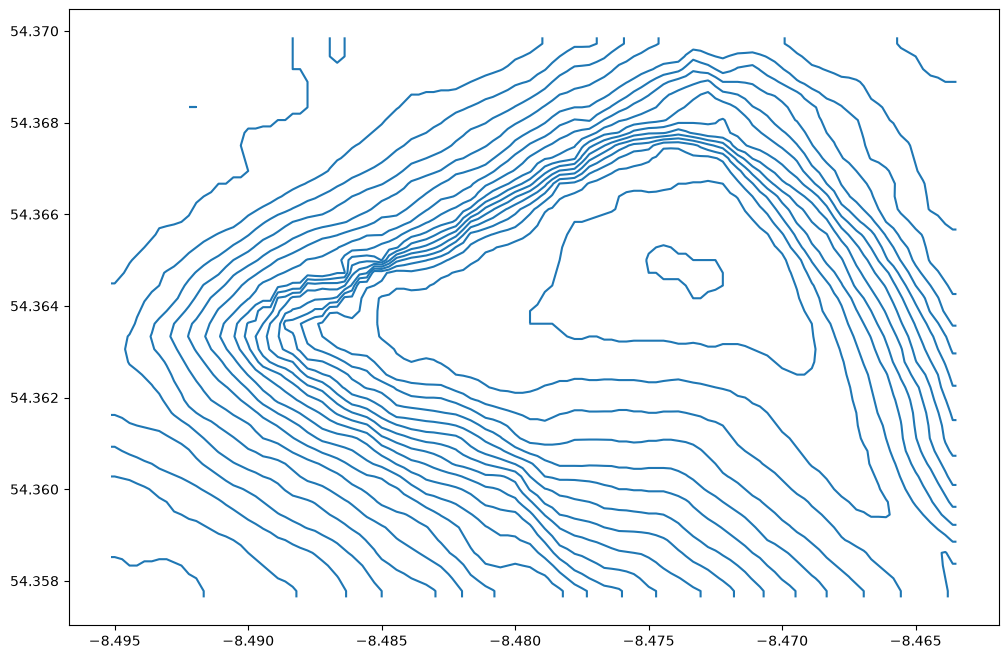

In [15]:
fig, ax = plt.subplots(figsize=(12, 12))
df = gpd.read_file("benbulbin_2_20_contour.shp")
df.plot(ax=ax)